In [1]:
import astropy.coordinates as coord
from astropy.io import fits
import matplotlib.pylab as plt
import matplotlib.cm as cm
import matplotlib as mlp
import pandas as pd
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
from matplotlib.patches import Polygon, Circle
from matplotlib.ticker import FormatStrFormatter
from astropy.coordinates import SkyCoord
import astropy.units as units
import os
from matplotlib.cm import ScalarMappable
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.ticker import ScalarFormatter

np.random.seed(42)

In [3]:
# all corners
fname = 'ztf_field_corners.csv'
data = pd.read_csv(fname)


files = os.listdir('../dr23-features/collected_by_field')
dr23_fields = [np.int64(filename[:-4].split('_')[-1]) for filename in files if filename.endswith('.dat')]

density = []
for filename in files:
    if filename.endswith('.dat') and 'oid' in filename.split('_'):
        density.append([np.int64(filename[:-4].split('_')[-1]),
                        len(np.memmap(f'../dr23-features/collected_by_field/{filename}', mode='c', dtype=np.uint64))])

density = pd.DataFrame(data=density, columns=['field', 'n']).sort_values('field').reset_index(drop=True)

# Data filtering
coord_corners = data[data['field'].isin(dr23_fields)]
coord_corners = coord_corners.reset_index(drop=True)
coord_corners['n'] = density['n']

def calculate_field_center(df):
    # Создаем копию dataframe чтобы не изменять исходный
    result = df.copy()
    
    # Список для хранения координат всех углов каждого поля
    all_ra = []
    all_dec = []
    
    # Собираем все координаты углов (предполагаем, что их всегда 4)
    for i in range(1, 5):
        all_ra.append(df[f'ra{i}'])
        all_dec.append(df[f'dec{i}'])
    
    # Объединяем координаты всех углов
    all_ra = np.array(all_ra)
    all_dec = np.array(all_dec)
    
    # Вычисляем среднее по всем углам для каждого поля
    result['center_ra'] = np.mean(all_ra, axis=0)
    result['center_dec'] = np.mean(all_dec, axis=0)
    
    return result


def split_polygon_at_180(ra, dec):
    # Проверяем пересечение RA=180°
    # if max(ra) > 180 and min(ra) < 180 and max(ra) < 250:
    #     return True

    if abs(ra.max() - ra.min()) > 200/180*np.pi:
        return True

    return False


# 3. Функция для преобразования координат
def convert_coords(ra_list, dec_list):
    coords = SkyCoord(ra=ra_list * units.deg, dec=dec_list * units.deg, frame='icrs')
    ra_rad = -coords.ra.wrap_at(180 * units.deg).radian
    dec_rad = coords.dec.radian
    return np.column_stack([ra_rad, dec_rad])

def convert_to_galactic(ra_list, dec_list):
    # Создаем объект SkyCoord в системе ICRS
    coords = SkyCoord(ra=ra_list * units.deg, dec=dec_list * units.deg, frame='icrs')
    
    # Преобразуем в галактическую систему координат
    galactic = coords.galactic
    
    # Получаем галактическую долготу (l) и широту (b) в радианах
    l_rad = galactic.l.deg
    b_rad = galactic.b.deg
    
    return np.column_stack([l_rad, b_rad])



center = calculate_field_center(coord_corners[coord_corners['field'].isin([795, 797, 799, 767, 759, 718, 626])])[['field', 'center_ra', 'center_dec']]
#convert_coords(center['center_ra'].tolist(), center['center_dec'].tolist())
center_gal = convert_to_galactic(center['center_ra'].tolist(), center['center_dec'].tolist())
center[['l', 'b']] = center_gal

# Прямое восхождение (RA) в градусах
ra_proj = [
    #300.0,        # Stripe 82 (среднее значение)
    150.1025,     # COSMOS
    #189.2054,     # GOODS-North (HDF-N)
    #53.1250,      # GOODS-South (CDF-S)
    #189.2372,     # Hubble Deep Field (HDF-N)
    #338.2942,     # Hubble Deep Field South (HDF-S)
    53.0833,      # Extended Chandra Deep Field South (ECDFS)
    #161.25,       # Lockman Hole
    242.5042,     # ELAIS-N1
   # 8.6833,       # ELAIS-S1
    #218.0220,      # Boötes Field (NDWFS)
    35.57,         # XMM_LSS
     #203.654,               # XMM‑Newton 13‑Hour Field
     #255,               # AUDS FIELD17H
    #125,            #AUDS GAL2577
    #146.3,         #  INTEGRAL M81 Field
    269.73,        # Euclid Deep Field North (EDFN)
    #260.7,         # JWST NEP Time‑Domain Field
]

# Склонение (Dec) в градусах
dec_proj = [
    #0.0,          # Stripe 82 (среднее значение)
    2.1758,       # COSMOS
    #62.2161,      # GOODS-North (HDF-N)
    #-27.8056,     # GOODS-South (CDF-S)
    #62.2131,      # Hubble Deep Field (HDF-N)
    #-60.5895,     # Hubble Deep Field South (HDF-S)
    -27.8094,     # Extended Chandra Deep Field South (ECDFS)
    #58.0,         # Lockman Hole
    54.5100,      # ELAIS-N1
    #-43.4700,     # ELAIS-S1
    #34.2799,       # Boötes Field (NDWFS)
    -4.82,         # XMM_LSS
    #37.884,               # XMM‑Newton 13‑Hour Field
    #19.7,               # AUDS FIELD17H
    #22.2,            #AUDS GAL2577
    #69.9,         #  INTEGRAL M81 Field
    66.02,        # Euclid Deep Field North (EDFN)	
    #65.82,         # JWST NEP Time‑Domain Field
]

proj_name = [
    #'Stripe 82',
    'LSST DDF-COSMOS, 9.6 deg$^2$',
    #'GOODS-North (HDF-N)',
    #'GOODS-South (CDF-S)',
    #'Hubble Deep Field (HDF-N)',
    #'Hubble Deep Field South (HDF-S)',
    'LSST DDF-ECDFS, 9.6 deg$^2$',
    #'Lockman Hole',
    'ELAIS-N1, 16 deg$^2$',
    #'ELAIS-S1',
    #'Boötes Field (NDWFS)',
    'LSST DDF-XMM-LSS, 9.6 deg$^2$',
    #'XMM‑Newton 13‑Hour Field',
    #'AUDS FIELD17H',
    #'AUDS GAL2577',
    #'INTEGRAL M81 Field',
    'Euclid DFN, 22.9 deg$^2$',
    #'JWST NEP Time‑Domain Field'
]

surf = [2, 0.3, 16, 11, 22.9]

surveys = dict(zip(proj_name,zip(ra_proj, dec_proj, surf)))

proj_plot_coord = convert_coords(ra_proj, dec_proj)


def get_square_corners(ra_center, dec_center, area_deg2):
    """
    Возвращает координаты 4 углов квадрата в экваториальной системе (RA, Dec).
    
    Параметры:
    - ra_center: прямое восхождение центра квадрата (в градусах)
    - dec_center: склонение центра квадрата (в градусах)
    - area_deg2: площадь квадрата (в квадратных градусах)
    
    Возвращает:
    - Список из 4 кортежей (RA, Dec) — координаты углов квадрата в порядке:
      верхний-левый, верхний-правый, нижний-правый, нижний-левый.
    """
    side_length_deg = np.sqrt(area_deg2)  # длина стороны квадрата в градусах
    delta_ra = side_length_deg / (2 * np.cos(np.radians(dec_center)))  # поправка на склонение
    
    # Угловые точки
    upper_left = [ra_center - delta_ra, dec_center + side_length_deg/2]
    upper_right = [ra_center + delta_ra, dec_center + side_length_deg/2]
    lower_right = [ra_center + delta_ra, dec_center - side_length_deg/2]
    lower_left = [ra_center - delta_ra, dec_center - side_length_deg/2]
    
    return np.array([upper_left, upper_right, lower_right, lower_left])


for name, item in surveys.items():
    coords = get_square_corners(*item)
    coords = convert_coords(coords[:, 0], coords[:, 1])
    surveys[name] = list(surveys[name]) + [coords]


split_180_mask = np.zeros(len(coord_corners), dtype=bool)
disk_mask = np.zeros(len(coord_corners), dtype=bool)
for ind, row in coord_corners.iterrows():
    # Получаем координаты вершин
    ra_coords = [row['ra1'], row['ra2'], row['ra3'], row['ra4']]
    dec_coords = [row['dec1'], row['dec2'], row['dec3'], row['dec4']]

    polygon_vertices = convert_coords(ra_coords, dec_coords)
    polygon_gal = convert_to_galactic(ra_coords, dec_coords)
    if (np.abs(polygon_gal[:,1]) < 20).all():
        disk_mask[ind] = True

    if not split_polygon_at_180(polygon_vertices[:, 0], polygon_vertices[:, 1]):
        split_180_mask[ind] = True


def bin_random_choice(arr, n_bins=10):
    bins = pd.qcut(arr['n'], q=n_bins, labels=False, duplicates='drop')  # qcut делит на равные части по количеству элементов
    
    selected_indices = []
    
    for b in range(bins.max() + 1):
        indices_in_bin = np.where(bins == b)[0]
        if len(indices_in_bin) > 0:
            selected_index = np.random.choice(indices_in_bin)
            selected_indices.append(selected_index)
    return arr.iloc[selected_indices]['field'].tolist()

# disk_fields = bin_random_choice(density[(split_180_mask * disk_mask)])
# ext_fields = bin_random_choice(density[(split_180_mask * ~disk_mask)])

disk_fields = [611, 459, 766, 853, 743, 684, 767, 589, 280, 488] 
ext_fields = [795, 797, 759, 718, 626, 252, 401, 468, 848, 673]

In [7]:
density[density['field'].isin(ext_fields)]['n'].sum()

np.int64(3992642)

NameError: name 'coord_corners' is not defined

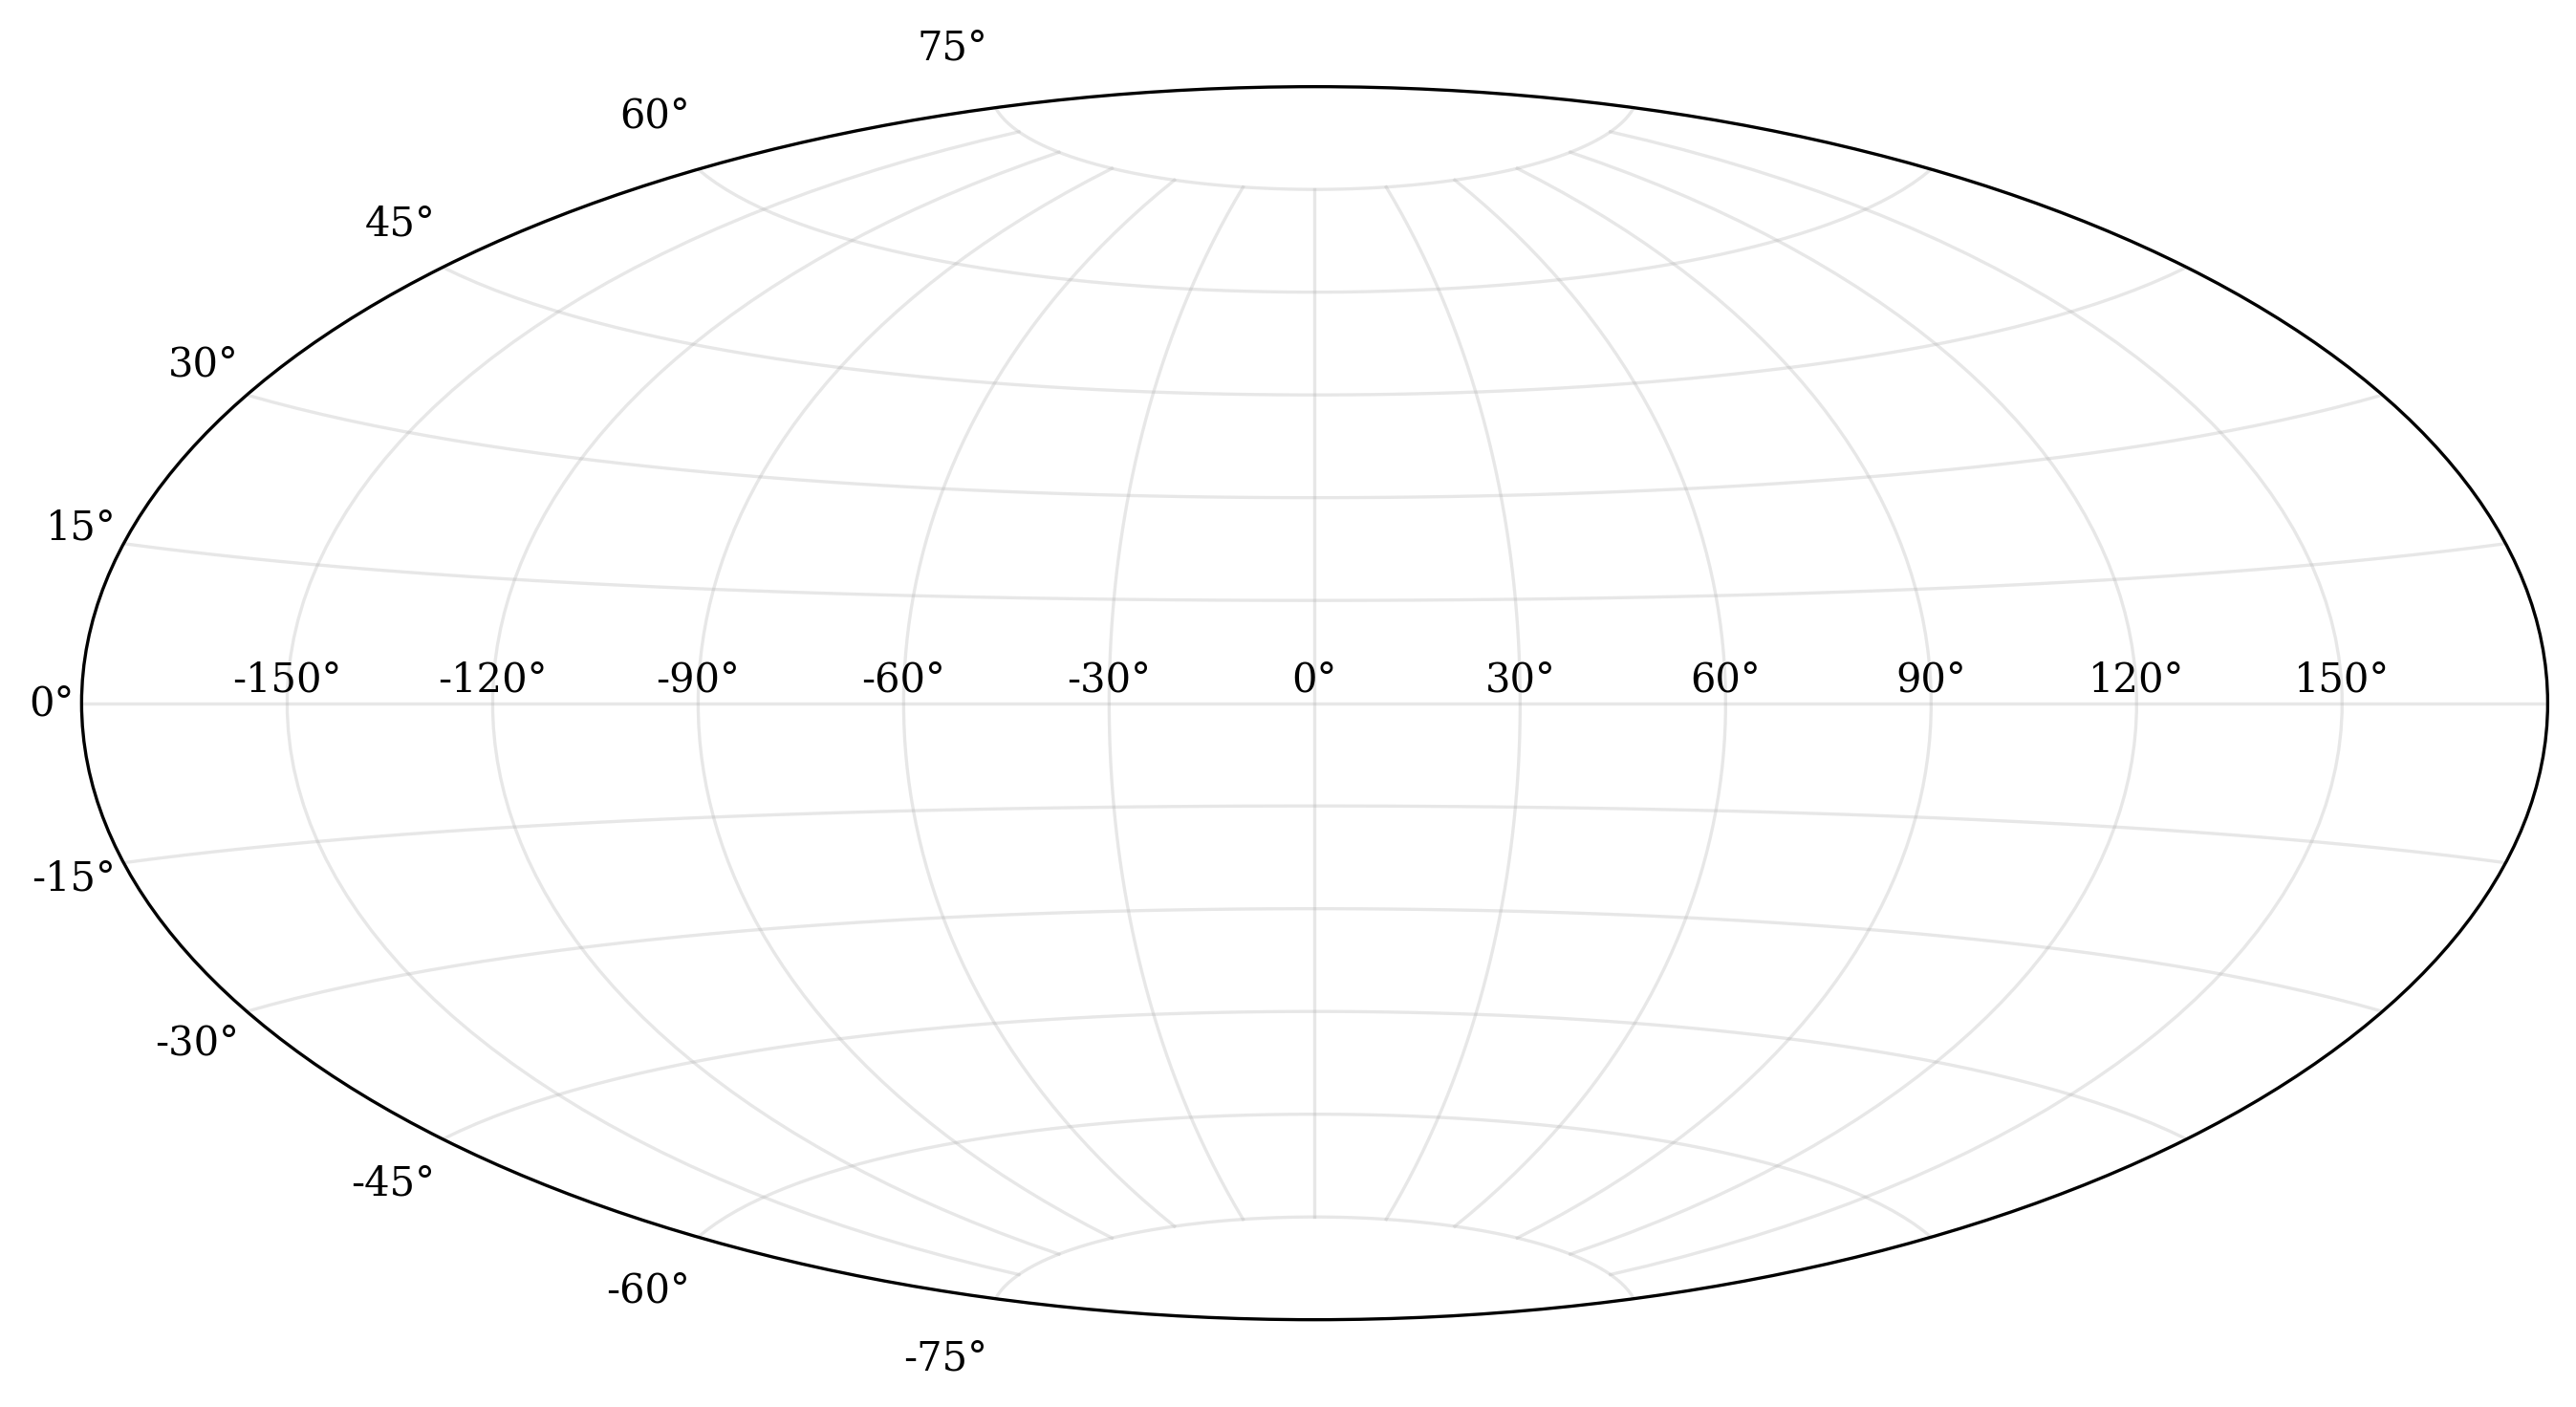

In [2]:
plt.rcParams["font.family"] = "DejaVu Serif"
plt.rcParams["mathtext.fontset"] = 'dejavuserif'

# Настройка графика
fig = plt.figure(figsize=(10, 6), dpi=300)
ax = fig.add_axes([0.07, 0.10, 0.86, 0.80], projection='aitoff')
ax.grid(zorder=0.5, alpha=0.3)

# Пример: галактическая плоскость
c_galactic = SkyCoord(l=np.linspace(-61.5, 296, 500)*units.deg, b=np.zeros(500)*units.deg, frame='galactic')
c_equatorial = c_galactic.icrs



# Инверсия RA (справа налево)
ra_plot = -c_equatorial.ra.wrap_at(180 * units.deg).radian
dec_plot = c_equatorial.dec.radian

# |b| = 20
curve_up = SkyCoord(l=np.linspace(-67, 290, 500)*units.deg, b=20*np.ones(500)*units.deg, frame='galactic') # (-15, 260, 100)
curve_up_eq = curve_up.icrs

curve_bot = SkyCoord(l=np.linspace(-57, 301, 500)*units.deg, b=-20*np.ones(500)*units.deg, frame='galactic') # (10, 235, 100)
curve_bot_eq = curve_bot.icrs

ra_up = -curve_up_eq.ra.wrap_at(180 * units.deg).radian
dec_up = curve_up_eq.dec.radian

ra_bot = -curve_bot_eq.ra.wrap_at(180 * units.deg).radian
dec_bot = curve_bot_eq.dec.radian


# l = const
l_const = SkyCoord(l=83.776285*np.ones(100)*units.deg, b=np.linspace(0, 90, 100)*units.deg, frame='galactic')
l_const_eq = l_const.icrs

ra_l_const = -l_const_eq.ra.wrap_at(180 * units.deg).radian
dec_l_const = l_const_eq.dec.radian

#####


# 3. Найдем диапазон плотностей для цветовой шкалы
densities = coord_corners['n']
vmin = int(np.floor(min(densities) / 1000) * 1000)
vmax = 10000000#int(np.ceil(max(densities) / 1000) * 1000)
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.Spectral
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])



edge_field_n = 0
for _, row in coord_corners.iterrows():
    # Получаем координаты вершин
    ra_coords = [row['ra1'], row['ra2'], row['ra3'], row['ra4']]
    dec_coords = [row['dec1'], row['dec2'], row['dec3'], row['dec4']]

    # if split_polygon_at_180(ra_coords, dec_coords):
    #     edge_field_n += 1
    #     continue
    
    # Преобразуем координаты
    polygon_vertices = convert_coords(ra_coords, dec_coords)
    # polygon_gal = convert_to_galactic(ra_coords, dec_coords)
    # if (np.abs(polygon_gal[:,1]) < 30).any():
    #     continue
    # Вычисляем центр полигона для подписи
    center_x = np.mean(polygon_vertices[:, 0])
    center_y = np.mean(polygon_vertices[:, 1])
    
    if split_polygon_at_180(polygon_vertices[:, 0], polygon_vertices[:, 1]):
        edge_field_n += 1
        continue

    
    # Создаем полигон
    poly = Polygon(
        polygon_vertices,
        #closed=True,
        #edgecolor='black',
        facecolor=cmap(norm(row['n'])),
        #linewidth=1,
        alpha=0.5
    )
    ax.add_patch(poly)


    plt.text(center_x, center_y, int(row['field']), 
           fontsize=4, ha='center', va='center', color='black')

    #if row['field'] in disk_fields:
    #    p1 = Polygon(polygon_vertices, edgecolor='black', fill=None, alpha=1, zorder=100, linewidth=1.5)
    #    ax.add_patch(p1)
    if row['field'] in ext_fields:
        p1 = Polygon(polygon_vertices, edgecolor='blue', fill=None, alpha=1, zorder=100, linewidth=1.5)
        if row['field'] == 759:
            p1 = Polygon(polygon_vertices, edgecolor='blue', fill=None, alpha=1, zorder=100, linewidth=1.5, label='Selected fields')
        ax.add_patch(p1)


# Построение
gc = SkyCoord(l=0*units.degree, b=0*units.degree, frame='galactic')
im_c = plt.scatter(-gc.icrs.ra.wrap_at(180 * units.deg).radian, 
                   gc.icrs.dec.radian, cmap='PuBu', s=25 ,
                   edgecolor=None, zorder=5, color='black', label='Galactic center')



# add M31
m31 = SkyCoord(l=(121.174329)*units.degree, 
               b=(-21.573309)*units.degree, frame='galactic')
# im_m = plt.scatter(-m31.icrs.ra.wrap_at(180 * units.deg).radian, 
#                    m31.icrs.dec.radian, cmap='PuBu', s=25,
#                    edgecolor=None, zorder=5, color = 'black', label='Andromeda', 
#                    alpha =0.7)



ax.plot(ra_plot, dec_plot, ls='-', c='black', label='Galactic Plane')


#bulge
radius_deg = 15
n_points = 360   
theta = np.linspace(0, 2 * np.pi, n_points)
l = radius_deg * np.cos(theta)
b = radius_deg * np.sin(theta)
bulge = SkyCoord(l=l*units.deg, b=b*units.deg, frame='galactic')
bulge_eq = bulge.icrs
bulge_ra, bulge_dec = -bulge_eq.ra.wrap_at(180 * units.deg).radian, bulge_eq.dec.radian

#ax.plot(bulge_ra, bulge_dec, color='black', linewidth=1.5, label=f'Bulge (R = {radius_deg} deg)')


ax.plot(ra_up, dec_up,  ls='--', c='black', label='$|b| = 20$ deg')
ax.plot(ra_bot, dec_bot, ls='--', c='black',)

ax.plot(ra_l_const, dec_l_const, ls='-.', c='black',label='$l = 84$ deg                                ')




# Подписи осей
ax.set_xticklabels(['14h', '16h', '18h', '20h', '22h', '0h', '2h', '4h', '6h', '8h', '10h'][::-1])
ax.set_xlabel('Right Ascension (RA)', fontsize=12)
ax.set_ylabel('Declination (Dec)', fontsize=12)
ax.tick_params(axis='both', labelsize=12)

# Шаг для колорбара (можно настроить под себя)
#step = (vmax - vmin) // 9  # 9 интервалов для 10 меток
#ticks = np.arange(vmin, vmax + step, step)
ticks = np.array([   10000,  1000000,  2000000,  3000000,  4000000,  5000000, 6000000, 7000000,
         8000000,  9000000,  10000000 ])

# cbar = plt.colorbar(sm, ax=ax, ticks=ticks)
# cbar.ax.set_yticklabels([f'{t:,}'.replace(',', ' ') for t in ticks])
# cbar.set_label("Number of objects", fontsize=12, rotation=270, labelpad=25)
# cbar.ax.tick_params(labelsize=12)

cbar = plt.colorbar(
    sm, 
    ax=ax, 
    ticks=ticks,
    orientation='horizontal',     # горизонтально
    pad=0.07,                     # расстояние до графика (можно регулировать)
    fraction=0.05,                # высота colorbar'а
    aspect=40,                    # длина colorbar'а (чем больше, тем длиннее)
    location='top'                # ключевой момент — рисует СВЕРХУ
)

# 4. Настраиваем подписи
cbar.ax.set_xticklabels([f'{t:,}'.replace(',', ' ') for t in ticks])
cbar.set_label("Number of objects", fontsize=12, labelpad=10)
cbar.ax.tick_params(labelsize=10, rotation=45)  # наклон для читаемости


plt.legend(bbox_to_anchor=(-0.05, -0.075), loc='lower right', fontsize=12, fancybox=True, framealpha=0.3, frameon=False)

plt.subplots_adjust(top=0.95, bottom=0.05, left=0.05, right=0.95)
#plt.savefig('ztf_dr23_field_map.png', dpi=400, format='png', bbox_inches="tight")

/tmp/ipykernel_11638/180843730.py:235: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  im_c = plt.scatter(-gc.icrs.ra.wrap_at(180 * units.deg).radian,


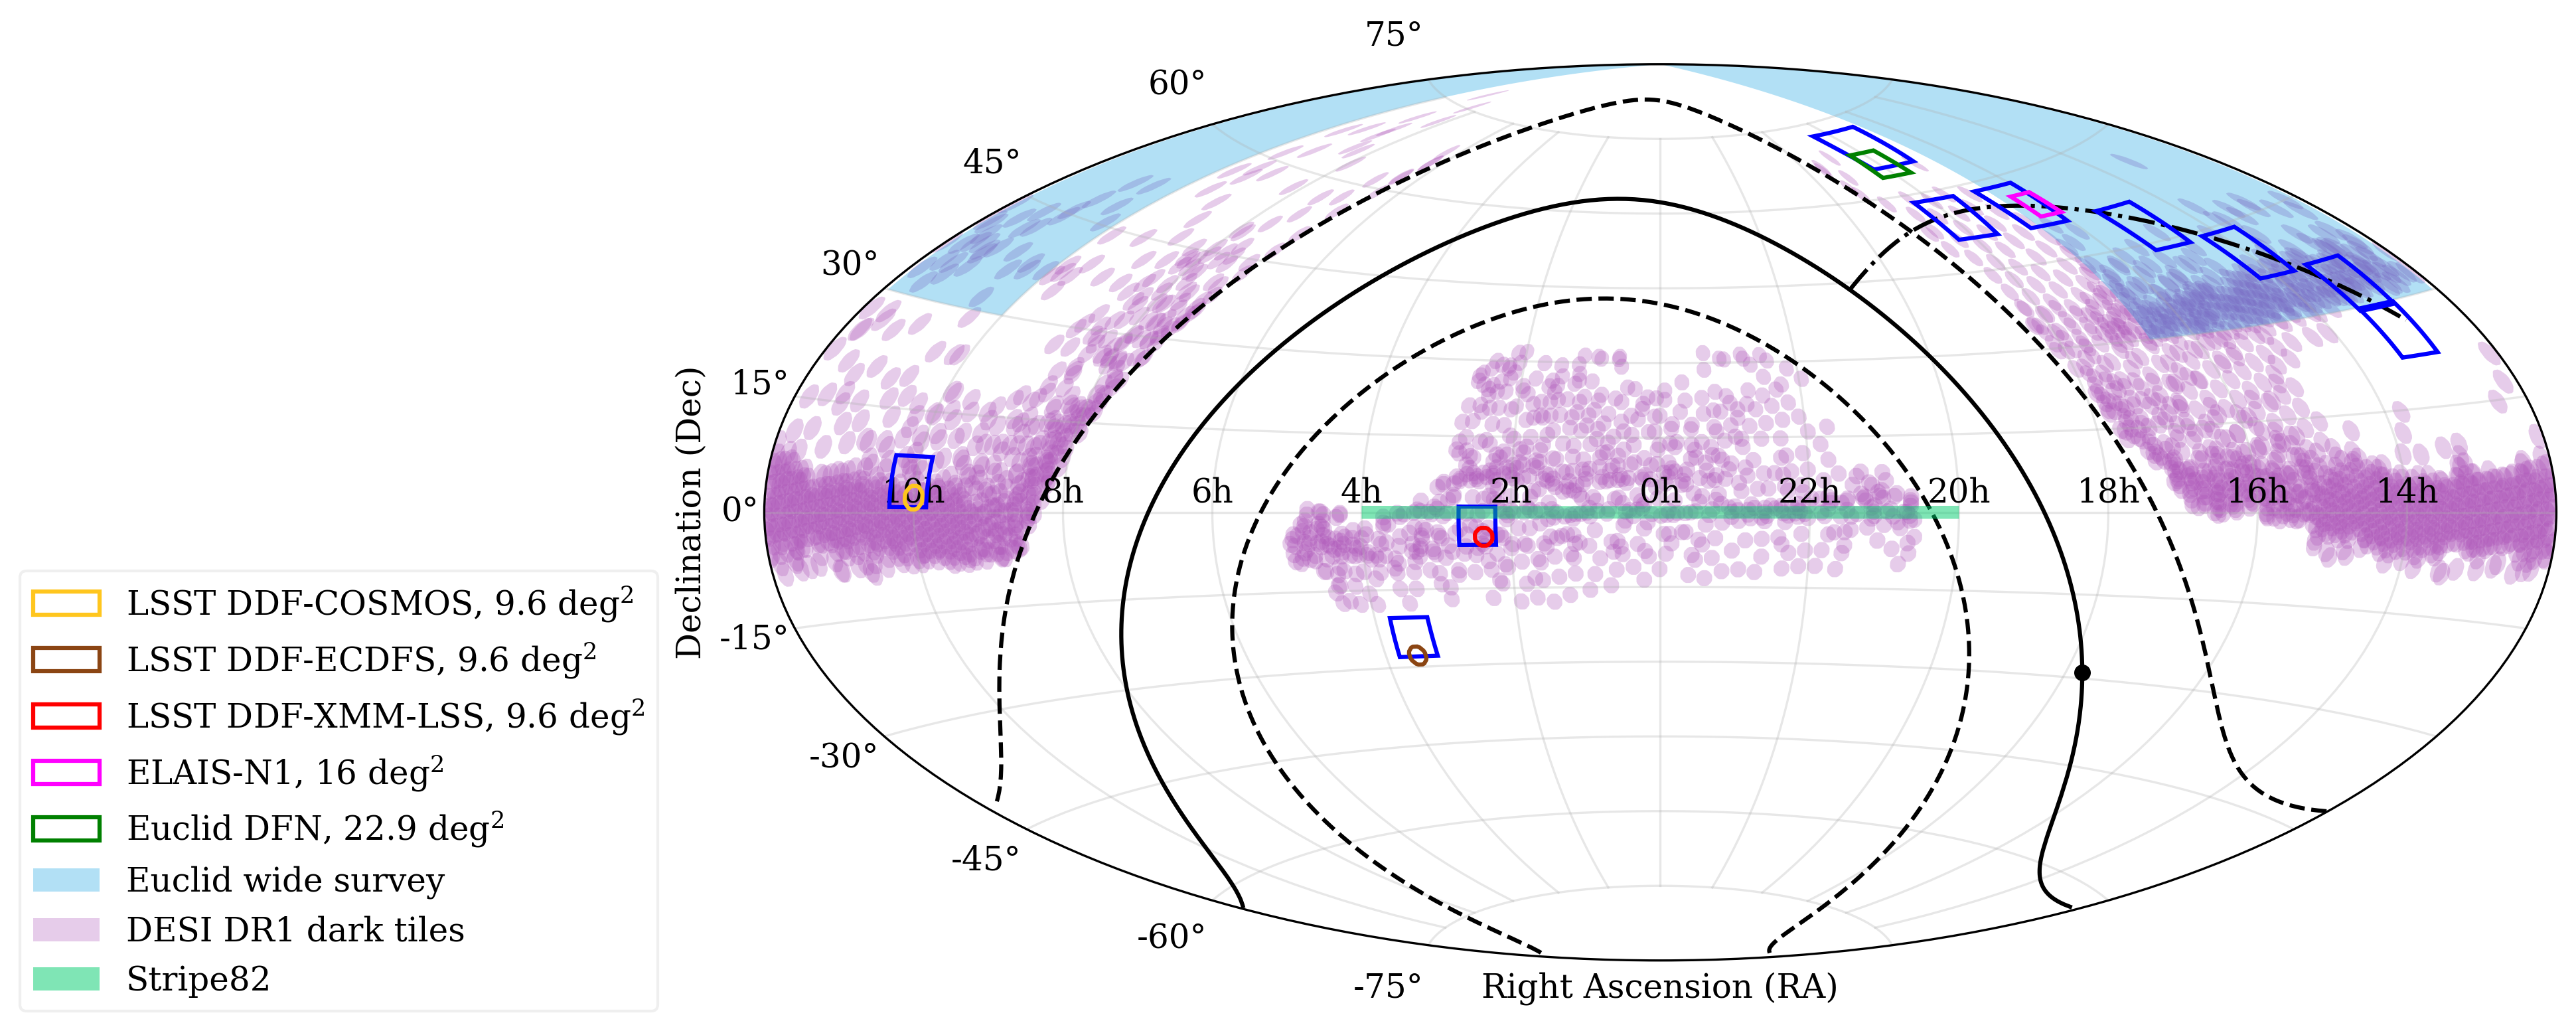

In [5]:
stripe82_ra = [300.0, 60.0, 60.0, 300.0]
stripe82_dec = [-1.25, -1.25, 1.25, 1.25]
stripe82 = convert_coords(stripe82_ra, stripe82_dec)

kepler = convert_coords([290.5], [44.5]) #https://archive.stsci.edu/missions-and-data/kepler/field

# Определяем границы областей Euclid Wide Survey (в градусах)
# https://hal.science/hal-03866201/file/aa41938-21.pdf
north_ra1 = np.linspace(150, 179, 100)  # Северная область RA
north_ra2 = np.linspace(181, 250, 100)  # Северная область RA
north_dec = np.linspace(30, 90, 100)   # Северная область Dec

north1 = convert_coords(north_ra1, north_dec)
north2 = convert_coords(north_ra2, north_dec)

south_ra1 = np.linspace(0, 100, 100)    # Южная область RA (часть 1)
south_ra2 = np.linspace(300, 360, 100)  # Южная область RA (часть 2)
south_dec = np.linspace(-90, -30, 100)  # Южная область Dec

south1 = convert_coords(south_ra1, south_dec)
south2 = convert_coords(south_ra2, south_dec)


# Создаем полигоны для закрашивания
def create_polygon(borders):
    ra_range, dec_range = borders[:, 0], borders[:, 1]
    # Верхняя граница слева направо
    top = np.column_stack([ra_range, np.full_like(ra_range, dec_range.max())])
    # Правая граница сверху вниз
    right = np.column_stack([np.full_like(dec_range, ra_range.max()), dec_range[::-1]])
    # Нижняя граница справа налево
    bottom = np.column_stack([ra_range[::-1], np.full_like(ra_range, dec_range.min())])
    # Левая граница снизу вверх
    left = np.column_stack([np.full_like(dec_range, ra_range.min()), dec_range])

    border = np.vstack([top, right, bottom, left, top[0:1]])  # Замыкаем полигон
    return border

# Северная область
north_vertices1 = create_polygon(north1)
north_patch1 = PathPatch(Path(north_vertices1),
                         facecolor='#009ADE',
                         alpha=0.3,
                         edgecolor='none',
                         label='Euclid wide survey')

north_vertices2 = create_polygon(north2)
north_patch2 = PathPatch(Path(north_vertices2),
                         facecolor='#009ADE',
                         alpha=0.3,
                         edgecolor='none')

# Южные области (две части)
south_vertices1 = create_polygon(south1)
south_patch1 = PathPatch(Path(south_vertices1),
                         facecolor='#009ADE',
                         alpha=0.3,
                         edgecolor='none')

south_vertices2 = create_polygon(south2)
south_patch2 = PathPatch(Path(south_vertices2),
                         facecolor='#009ADE',
                         alpha=0.3,
                         edgecolor='none')


#Roman survey (High-Latitude Wide-Area Survey )
# https://science.nasa.gov/mission/roman-space-telescope/high-latitude-wide-area-survey/

#DESI DR1 main survey: dark tiles
# https://arxiv.org/pdf/2503.14745
# https://data.desi.lbl.gov/doc/releases/dr1/
file = "tiles-iron.fits"

with fits.open(file) as hdul:
    data = hdul[1].data

# Convert to ndarray
arr = np.array(data)

# Swap bytes and update dtype to native byte order
arr = arr.byteswap().view(arr.dtype.newbyteorder('='))

# Convert to DataFrame
df = pd.DataFrame(arr)
for col in df.select_dtypes([object]):
    if isinstance(df[col].iloc[0], bytes):
        df[col] = df[col].str.decode('utf-8')

# Filter the DataFrame
dark_tiles = df[(df['SURVEY'] == 'main') & (df['PROGRAM'] == 'dark')]


# Настройка графика
plt.rcParams["font.family"] = "DejaVu Serif"
plt.rcParams["mathtext.fontset"] = 'dejavuserif'
plt.rcParams["font.size"] = 12

plt.figure(figsize=(10, 6), dpi=300)
ax = plt.subplot(111, projection='aitoff')
ax.grid(zorder=0.5, alpha=0.3)


edge_field_n = 0
for _, row in coord_corners.iterrows():
    # Получаем координаты вершин
    ra_coords = [row['ra1'], row['ra2'], row['ra3'], row['ra4']]
    dec_coords = [row['dec1'], row['dec2'], row['dec3'], row['dec4']]

    # if split_polygon_at_180(ra_coords, dec_coords):
    #     edge_field_n += 1
    #     continue
    
    # Преобразуем координаты
    polygon_vertices = convert_coords(ra_coords, dec_coords)
    # polygon_gal = convert_to_galactic(ra_coords, dec_coords)
    # if (np.abs(polygon_gal[:,1]) < 30).any():
    #     continue
    # Вычисляем центр полигона для подписи
    center_x = np.mean(polygon_vertices[:, 0])
    center_y = np.mean(polygon_vertices[:, 1])
    
    if split_polygon_at_180(polygon_vertices[:, 0], polygon_vertices[:, 1]):
        edge_field_n += 1
        continue

    




    #if row['field'] in disk_fields:
    #    p1 = Polygon(polygon_vertices, edgecolor='black', fill=None, alpha=1, zorder=100, linewidth=1.5)
    #    ax.add_patch(p1)
    if row['field'] in ext_fields:
        p1 = Polygon(polygon_vertices, edgecolor='blue', fill=None, alpha=1, zorder=100, linewidth=1.5)
        ax.add_patch(p1)


#Different sky surveys
survey_ordered = [
    'LSST DDF-COSMOS, 9.6 deg$^2$',
    'LSST DDF-ECDFS, 9.6 deg$^2$',
    'LSST DDF-XMM-LSS, 9.6 deg$^2$',
    'ELAIS-N1, 16 deg$^2$',
    'Euclid DFN, 22.9 deg$^2$',
]
colors = ['#FFC61E','saddlebrown',  'red', '#FF00FF', 'green']
for i, name in enumerate(survey_ordered):
    item = surveys[name]
    if name[:4] == 'LSST':
        coords = convert_coords([item[0]], [item[1]])
        ax.add_patch(Circle(coords[0],
                     np.radians(np.sqrt(9.6 / np.pi)),
                     edgecolor=colors[i],
                     fill=None,
                     alpha=1,
                     zorder=101,
                     linewidth=1.5,
                     label=name)
                    )
        continue


    p1 = Polygon(item[3],
                 edgecolor=colors[i],
                 fill=None,
                 alpha=1,
                 zorder=101,
                 linewidth=1.5,
                 label=name)
    ax.add_patch(p1)


# Euclid wide survey
ax.add_patch(north_patch1)
ax.add_patch(north_patch2)
#ax.add_patch(south_patch1)
#ax.add_patch(south_patch2)



#DESI dark tiles
for i, tile in enumerate(dark_tiles.iterrows()):
    coord = tile[1][['TILERA', 'TILEDEC']].tolist()
    coord = convert_coords([coord[0]], [coord[1]])[0]
    if i == 0:
        ax.add_patch(Circle(coord,
                     np.radians(1.6),
                     facecolor='#AF58BA',
                     #fill=None,
                     alpha=0.3,
                     zorder=0.5,
                     linewidth=1.5,
                     label='DESI DR1 dark tiles')
                    )
        continue

    ax.add_patch(Circle(coord,
                     np.radians(1.6),
                     facecolor='#AF58BA',
                     #fill=None,
                     alpha=0.3,
                     zorder=0.5,
                     linewidth=1.5,
                     )
                    )


#Stripe82
p1 = Polygon(stripe82,
                 #edgecolor='purple',
                 facecolor='#00CD6C',
                 alpha=0.5,
                 zorder=101,
                 #linewidth=1.5,
                 label='Stripe82')
ax.add_patch(p1)

#Kepler K1
# ax.add_patch(Circle(kepler[0],
#                      np.radians(np.sqrt(116 / np.pi)),
#                      facecolor='#FF1F5B',
#                      #fill=None,
#                      alpha=0.8,
#                      zorder=101,
#                      linewidth=1.5,
#                      label='Kepler K1')
#                     )




gc = SkyCoord(l=0*units.degree, b=0*units.degree, frame='galactic')
im_c = plt.scatter(-gc.icrs.ra.wrap_at(180 * units.deg).radian, 
                   gc.icrs.dec.radian, cmap='PuBu', s=25,
                   edgecolor=None, zorder=5, color='black')

# Построение
ax.plot(ra_plot, dec_plot, ls='-', c='black')

#ax.plot(bulge_ra, bulge_dec, color='black', linewidth=1.5, label=f'Bulge (R = {radius_deg} deg)')

ax.plot(ra_up, dec_up,  ls='--', c='black')
ax.plot(ra_bot, dec_bot, ls='--', c='black',)

ax.plot(ra_l_const, dec_l_const, ls='-.', c='black')


# Подписи осей
ax.set_xticklabels(['14h', '16h', '18h', '20h', '22h', '0h', '2h', '4h', '6h', '8h', '10h'][::-1])
ax.set_xlabel('Right Ascension (RA)', fontsize=12)
ax.set_ylabel('Declination (Dec)', fontsize=12)
ax.tick_params(axis='both', labelsize=12)

plt.legend(bbox_to_anchor=(-0.05, -0.075), loc='lower right', fancybox=True, framealpha=0.3)

plt.subplots_adjust(top=0.95, bottom=0.05, left=0.05, right=0.95)
plt.savefig('surveys_map.png', dpi=400, format='png', bbox_inches="tight")